# Word Vectors: The King − Man + Woman = Queen Demo

This notebook gives an interactive look at **word embeddings** through the lens of the classic analogy that made word2vec famous in 2013.

We'll use a pre-trained **GloVe** model (Stanford, ~66 MB download) loaded through `gensim`. GloVe and word2vec are different training algorithms, but the resulting vector spaces behave the same way — and GloVe is the smallest model that reliably nails the king/queen example without a multi-gigabyte download.

**What you'll see:**
- Vectors as coordinates in high-dimensional space
- Arithmetic on meaning: `king − man + woman ≈ queen`
- A handful of other analogies that work for the same reason
- A quick 2-D picture of where the words land

In [ ]:
# One-time install — comment out after first run if you prefer
# gensim is the only new dependency; everything else is already in requirements.txt
%pip install -q gensim scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# glove-wiki-gigaword-50  →  50-dimensional vectors, ~66 MB
# Downloads once and caches in ~/.cache/gensim-data/
print("Loading model (downloads once, ~66 MB) …")
wv = api.load("glove-wiki-gigaword-50")
print(f"Done. Vocabulary size: {len(wv):,}  |  Vector dimensions: {wv.vector_size}")

Loading model (downloads once, ~66 MB) …
[==================================================] 100.0% 66.0/66.0MB downloaded
Done. Vocabulary size: 400,000  |  Vector dimensions: 50


## A Word Vector
A single word vector has 50 dimensions:

In [8]:
print(wv.get_vector('king'))  # 50-dimensional vector for "king"

[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]


## The Classic Analogy

The model learned vectors purely from word co-occurrence in text — no labels, no grammar rules.  
Yet the geometry captures meaning:

```
king − man + woman  ≈  ??
```

`most_similar(positive=[…], negative=[…])` does this arithmetic and returns the nearest neighbors.

In [5]:
result = wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

print("king − man + woman  →  top 5 nearest vectors")
print("-" * 38)
for word, score in result:
    print(f"  {word:<15}  similarity: {score:.4f}")

king − man + woman  →  top 5 nearest vectors
--------------------------------------
  queen            similarity: 0.8524
  throne           similarity: 0.7664
  prince           similarity: 0.7592
  daughter         similarity: 0.7474
  elizabeth        similarity: 0.7460


## More Analogies

The same trick works across many knowledge domains.

In [9]:
analogies = [
    # (A, B, C)  → model should return something ≈ D
    # "A is to B as C is to ?"
    ("paris",   "france",   "berlin",    "geography"),
    ("man",     "actor",    "woman",     "gender/roles"),
    ("walking", "walked",   "running",   "verb tense"),
    ("tall",    "taller",   "fast",      "comparatives"),
    ("doctor",  "hospital", "teacher",  "workplaces"),
]

print(f"  {'Analogy':<38}  Top answer         Score")
print("-" * 72)
for a, b, c, label in analogies:
    # b − a + c  = ?
    top = wv.most_similar(positive=[b, c], negative=[a], topn=1)
    word, score = top[0]
    print(f"  {a} → {b}  //  {c} → ?   [{label:<14}]  {word:<18} {score:.4f}")

  Analogy                                 Top answer         Score
------------------------------------------------------------------------
  paris → france  //  berlin → ?   [geography     ]  germany            0.9212
  man → actor  //  woman → ?   [gender/roles  ]  actress            0.9419
  walking → walked  //  running → ?   [verb tense    ]  run                0.7947
  tall → taller  //  fast → ?   [comparatives  ]  quicker            0.8618
  doctor → hospital  //  teacher → ?   [workplaces    ]  school             0.8016


## Vector Arithmetic in Plain NumPy

You don't need `most_similar` — it's just dot products.  
Here's the same operation written out by hand so you can see exactly what's happening.

In [10]:
v_king  = wv["king"]
v_man   = wv["man"]
v_woman = wv["woman"]
v_queen = wv["queen"]

# The alleged result
v_result = v_king - v_man + v_woman

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"Cosine similarity between (king−man+woman) and 'queen': {cosine(v_result, v_queen):.4f}")
print(f"Cosine similarity between 'king' and 'queen':           {cosine(v_king,   v_queen):.4f}")
print(f"Cosine similarity between 'king' and 'man':             {cosine(v_king,   v_man):.4f}")

Cosine similarity between (king−man+woman) and 'queen': 0.8610
Cosine similarity between 'king' and 'queen':           0.7839
Cosine similarity between 'king' and 'man':             0.5309


## 2-D Picture

50 dimensions → 2 dimensions via PCA.  
The parallelogram formed by `man → king` and `woman → queen` is the geometric story.

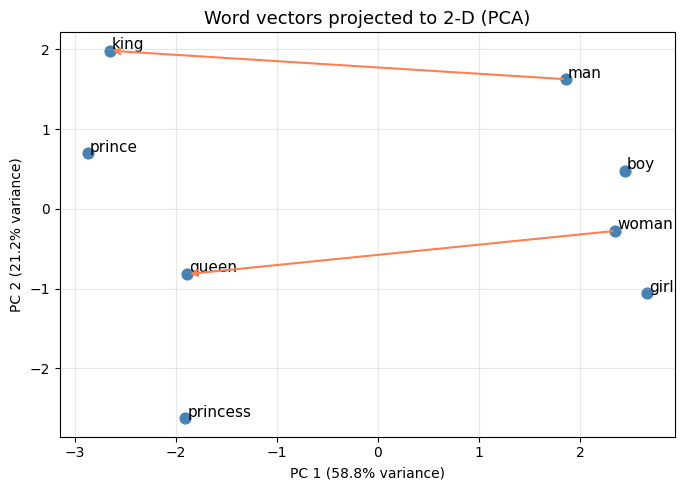

In [11]:
words = ["king", "queen", "man", "woman", "prince", "princess", "boy", "girl"]
vectors = np.array([wv[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords[:, 0], coords[:, 1], s=60, color="steelblue")

for i, word in enumerate(words):
    ax.annotate(word, (coords[i, 0] + 0.02, coords[i, 1] + 0.02), fontsize=11)

# Draw the analogy parallelogram
def idx(w): return words.index(w)
pairs = [("man", "king"), ("woman", "queen")]
for a, b in pairs:
    ax.annotate("", xy=coords[idx(b)], xytext=coords[idx(a)],
                arrowprops=dict(arrowstyle="->", color="coral", lw=1.5))

ax.set_title("Word vectors projected to 2-D (PCA)", fontsize=13)
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Takeaways

| Concept | What we saw |
|---------|-------------|
| **Embeddings are coordinates** | Each word is a point in 50-D space |
| **Direction encodes meaning** | `king − man ≈ queen − woman` (a "royalty" direction) |
| **Similarity = cosine of angle** | Closer vectors ≈ more similar meaning |
| **No labels needed** | The model learned this from raw text co-occurrence |

When the Google embedding API returns a 768-dimension vector for a full paragraph, the same geometry applies — just at much larger scale. That's the foundation for the semantic search and RAG systems we'll build next.